# Notebook 02: Read and Validate CryoSat-2 Baseline-E L2E

Validates that `read_cs2_l2e()` correctly reads CS2 NetCDF files
with Antarctic filtering.

## 2.1 Setup

In [1]:
import sys, glob, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, '/g/data/gv90/xl1657/phd/M2_workspace/notebooks')
from utils import read_cs2_l2e

print('Imports successful')


Imports successful


## 2.2 Define Data Paths

In [2]:
CS2_DIR = '/g/data/gv90/xl1657/phd/M2_workspace/data/raw/CS2_L2E'

files = sorted(glob.glob(f'{CS2_DIR}/**/*.nc', recursive=True))
if not files:
    files = sorted(glob.glob(f'{CS2_DIR}/*.nc'))

print(f'Found {len(files)} CS2 L2E files')
print(f'First: {files[0]}')
print(f'Last:  {files[-1]}')


Found 150648 CS2 L2E files
First: /g/data/gv90/xl1657/phd/M2_workspace/data/raw/CS2_L2E/CS_OFFL_SIR_SAR_2__20220801T000439_20220801T000534_E001.nc
Last:  /g/data/gv90/xl1657/phd/M2_workspace/data/raw/CS2_L2E/CS_OFFL_SIR_SAR_2__20250930T235542_20251001T000001_E001.nc


In [3]:
from netCDF4 import Dataset

with Dataset(files[0], 'r') as ds:
    print("=== All variables ===")
    for name in sorted(ds.variables.keys()):
        var = ds.variables[name]
        print(f"  {name}: shape={var.shape}, dims={var.dimensions}")

=== All variables ===
  alt_01: shape=(62,), dims=('time_cor_01',)
  echo_avg_numval_20_ku: shape=(1236,), dims=('time_20_ku',)
  flag_cor_applied_20_ku: shape=(1236,), dims=('time_20_ku',)
  flag_cor_err_01: shape=(62,), dims=('time_cor_01',)
  flag_instr_conf_rx_str_in_use_01: shape=(62,), dims=('time_cor_01',)
  flag_instr_mode_op_20_ku: shape=(1236,), dims=('time_20_ku',)
  flag_prod_status_20_ku: shape=(1236,), dims=('time_20_ku',)
  geoid_01: shape=(62,), dims=('time_cor_01',)
  height_1_20_ku: shape=(1236,), dims=('time_20_ku',)
  height_2_20_ku: shape=(1236,), dims=('time_20_ku',)
  height_3_20_ku: shape=(1236,), dims=('time_20_ku',)
  height_sea_ice_floe_20_ku: shape=(1236,), dims=('time_20_ku',)
  height_sea_ice_lead_20_ku: shape=(1236,), dims=('time_20_ku',)
  hf_fluct_total_cor_01: shape=(62,), dims=('time_cor_01',)
  ind_first_meas_20hz_01: shape=(62,), dims=('time_cor_01',)
  ind_meas_1hz_20_ku: shape=(1236,), dims=('time_20_ku',)
  inv_bar_cor_01: shape=(62,), dims=('tim

In [4]:
from netCDF4 import Dataset
import numpy as np

with Dataset(files[0], 'r') as ds:
    lat = ds.variables['lat_poca_20_ku'][:]
    rfb = ds.variables['radar_freeboard_20_ku'][:]
    surf = ds.variables['surf_type_20_ku'][:]
    
    print(f"Total measurements: {len(lat)}")
    print(f"Lat range: {lat.min():.2f} to {lat.max():.2f}")
    print(f"Lat < -50: {(lat < -50).sum()}")
    print()
    print(f"Surf type unique values: {np.unique(surf)}")
    print(f"Surf type == 2: {(surf == 2).sum()}")
    print()
    print(f"Freeboard range: {rfb.min():.4f} to {rfb.max():.4f}")
    print(f"Freeboard finite: {np.isfinite(rfb).sum()}")
    print()
    print(f"Combined (surf==2 & lat<-50 & finite): "
          f"{((surf == 2) & (lat < -50) & np.isfinite(rfb)).sum()}")
    print(f"Combined (lat<-50 & finite, no surf): "
          f"{((lat < -50) & np.isfinite(rfb)).sum()}")

Total measurements: 1236
Lat range: 67.19 to 70.52
Lat < -50: 0

Surf type unique values: [0 1 2 3]
Surf type == 2: 6

Freeboard range: -- to --
Freeboard finite: --

Combined (surf==2 & lat<-50 & finite): --
Combined (lat<-50 & finite, no surf): --


/jobfs/162907692.gadi-pbs/ipykernel_1299833/2752109220.py:16: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  print(f"Freeboard range: {rfb.min():.4f} to {rfb.max():.4f}")


In [5]:
from netCDF4 import Dataset
import numpy as np

n_antarctic = 0
n_arctic = 0
n_mixed = 0

for i, f in enumerate(files[:50]):  # check first 50 files
    with Dataset(f, 'r') as ds:
        lat = ds.variables['lat_poca_20_ku'][:]
        lat_min = lat.min()
        lat_max = lat.max()
        
        if lat_max < -50:
            n_antarctic += 1
        elif lat_min > 50:
            n_arctic += 1
        else:
            n_mixed += 1
    
    if (i + 1) % 10 == 0:
        print(f'Checked {i+1}/50 files...')

print(f'\nFirst 50 files:')
print(f'  Antarctic (lat < -50): {n_antarctic}')
print(f'  Arctic (lat > 50):     {n_arctic}')
print(f'  Mixed/other:           {n_mixed}')
print(f'\nFirst Antarctic file example:')

# Find and show the first Antarctic file
for f in files:
    with Dataset(f, 'r') as ds:
        lat = ds.variables['lat_poca_20_ku'][:]
        if lat.max() < -50:
            print(f'  {f}')
            print(f'  Lat range: {lat.min():.2f} to {lat.max():.2f}')
            print(f'  Measurements: {len(lat)}')
            break

Checked 10/50 files...
Checked 20/50 files...
Checked 30/50 files...
Checked 40/50 files...
Checked 50/50 files...

First 50 files:
  Antarctic (lat < -50): 20
  Arctic (lat > 50):     22
  Mixed/other:           8

First Antarctic file example:
  /g/data/gv90/xl1657/phd/M2_workspace/data/raw/CS2_L2E/CS_OFFL_SIR_SAR_2__20220801T004041_20220801T004201_E001.nc
  Lat range: -65.13 to -60.32
  Measurements: 1723


## 2.3 Test on a Single File

In [6]:
# Find first Antarctic file
from netCDF4 import Dataset as DS
for f in files:
    with DS(f, 'r') as ds:
        lat = ds.variables['lat_poca_20_ku'][:]
        if lat.max() < -50:
            test_file = f
            break

print(f'Testing: {test_file}')
df_test = read_cs2_l2e(test_file)

print(f'Measurements: {len(df_test)}')
print(f'Columns: {list(df_test.columns)}')
print(f'Lat range: {df_test.lat.min():.2f} to {df_test.lat.max():.2f}')
print(f'Radar freeboard median: {df_test.rfb.median():.4f} m')
print(f'Radar freeboard mean:   {df_test.rfb.mean():.4f} m')

Testing: /g/data/gv90/xl1657/phd/M2_workspace/data/raw/CS2_L2E/CS_OFFL_SIR_SAR_2__20220801T004041_20220801T004201_E001.nc
Measurements: 107
Columns: ['lat', 'lon', 'rfb', 'time_tai']
Lat range: -65.08 to -63.54
Radar freeboard median: 0.0550 m
Radar freeboard mean:   -0.0077 m


In [7]:
from netCDF4 import Dataset
import numpy as np

with Dataset(test_file, 'r') as ds:
    lat = np.array(ds.variables['lat_poca_20_ku'][:])
    rfb = np.array(ds.variables['radar_freeboard_20_ku'][:], dtype=float)
    surf = np.array(ds.variables['surf_type_20_ku'][:])
    
    rfb[rfb > 1e10] = np.nan
    
    print(f"Total: {len(lat)}")
    print(f"Lat < -50: {(lat < -50).sum()}")
    print(f"Surf type unique: {np.unique(surf)}")
    for s in np.unique(surf):
        print(f"  surf_type == {s}: {(surf == s).sum()}")
    print(f"rfb finite: {np.isfinite(rfb).sum()}")
    print(f"Combined (surf==2 & lat<-50 & finite): "
          f"{((surf == 2) & (lat < -50) & np.isfinite(rfb)).sum()}")
    print(f"Combined (lat<-50 & finite, no surf filter): "
          f"{((lat < -50) & np.isfinite(rfb)).sum()}")

Total: 1723
Lat < -50: 1723
Surf type unique: [0]
  surf_type == 0: 1723
rfb finite: 1723
Combined (surf==2 & lat<-50 & finite): 0
Combined (lat<-50 & finite, no surf filter): 1723


## 2.4 Visualisation

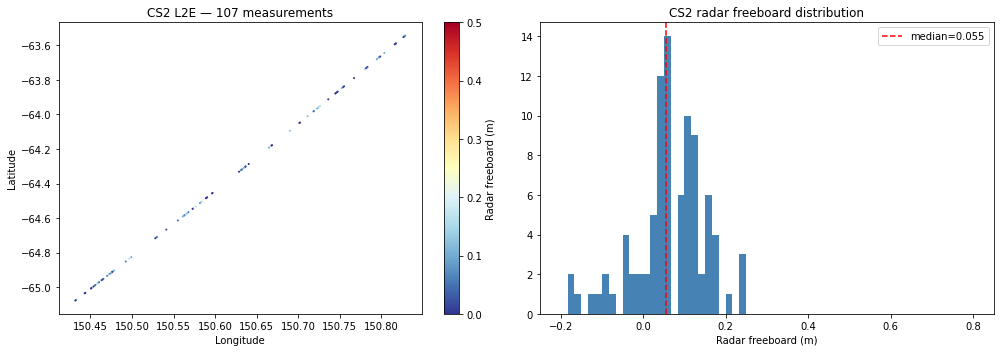

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sc = ax.scatter(df_test.lon, df_test.lat, c=df_test.rfb,
                s=1, cmap='RdYlBu_r', vmin=0, vmax=0.5)
plt.colorbar(sc, ax=ax, label='Radar freeboard (m)')
ax.set_title(f'CS2 L2E — {len(df_test)} measurements')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

ax = axes[1]
ax.hist(df_test.rfb, bins=60, range=(-0.2, 0.8), color='steelblue')
ax.axvline(df_test.rfb.median(), color='red', ls='--', label=f'median={df_test.rfb.median():.3f}')
ax.set_xlabel('Radar freeboard (m)'); ax.legend()
ax.set_title('CS2 radar freeboard distribution')

plt.tight_layout()
plt.savefig('/g/data/gv90/xl1657/phd/M2_workspace/output/figures/02_cs2_l2e_validation.png', dpi=300)
plt.show()


## 2.5 Batch Test: August 2022

In [9]:
aug_files = [f for f in files if '202208' in f or '2022_08' in f]
print(f'August 2022 CS2 files: {len(aug_files)}')

t0 = time.time()
frames = [read_cs2_l2e(f) for f in aug_files]
df_cs2_aug = pd.concat([f for f in frames if len(f) > 0], ignore_index=True)
print(f'Total CS2 measurements (Aug 2022): {len(df_cs2_aug)}')
print(f'Time: {time.time()-t0:.1f}s')


August 2022 CS2 files: 3390
Total CS2 measurements (Aug 2022): 600981
Time: 153.6s


## 2.6 Validation

In [10]:
assert df_test.lat.max() < -50, 'ERROR: Non-Antarctic data'
assert df_test.rfb.median() > -0.5, 'ERROR: Radar freeboard too negative'
assert df_test.rfb.median() < 1.0, 'ERROR: Radar freeboard too high'
print('ALL VALIDATIONS PASSED')


ALL VALIDATIONS PASSED
